In [1]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:", env.action_space)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


### Task 1 — DQN from Scratch on CartPole-v1

Build a DQN agent following the recipe from the lesson — Q-network, replay buffer, target network, ε-greedy exploration.

1. Implement a small Q-network in PyTorch: input dimension = `env.observation_space.shape[0]`, two hidden layers of 128 units with ReLU, output dimension = `env.action_space.n`.
2. Implement a `ReplayBuffer` class that supports `push(state, action, reward, next_state, done)` and `sample(batch_size)`. A `collections.deque(maxlen=50_000)` is plenty for CartPole.
3. Implement the training loop:
   - Keep two networks: `q_net` (trained) and `target_net` (frozen, periodically synced from `q_net`).
   - Use ε-greedy action selection with linear ε decay from `1.0` to `0.05` over the first ~5 000 steps.
   - After at least 1 000 transitions are in the buffer, do one gradient step per environment step on a random mini-batch of 64.
   - Sync `target_net ← q_net` every 1 000 steps.
   - Use `Adam(lr=1e-3)` and γ = 0.99.
4. Run training for **30 000 environment steps** and store the **total reward per episode** in a list.

**Expected behaviour.** A correctly implemented DQN solves `CartPole-v1` (average reward ≥ 475 over 100 episodes) somewhere between 10 000 and 25 000 steps. If your reward is still flat at the end, double-check the target-network sync, the ε decay, and the loss (it should be MSE between `q_net(s).gather(action)` and `r + γ · target_net(s').max()` for non-terminal transitions; just `r` for terminal ones).

5. Plot the per-episode reward and a 100-episode moving average on the same axes. Report the average reward over the last 100 episodes.


In [3]:
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

In [4]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.tensor(states, dtype=torch.float32).to(device),
            torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(device),
            torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device),
            torch.tensor(next_states, dtype=torch.float32).to(device),
            torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

In [6]:
q_net = QNetwork(obs_dim, n_actions).to(device)
target_net = QNetwork(obs_dim, n_actions).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer = ReplayBuffer()

gamma = 0.99
batch_size = 64

# ε-greedy
eps_start = 1.0
eps_end = 0.05
eps_decay_steps = 5000

def get_epsilon(step):
    return max(eps_end, eps_start - (eps_start - eps_end) * step / eps_decay_steps)


In [7]:
total_steps = 30_000
sync_freq = 1000
start_learning = 1000

episode_rewards = []
episode_reward = 0

state, _ = env.reset(seed=42)
t0 = time.perf_counter()
for step in range(1, total_steps + 1):
    epsilon = get_epsilon(step)

    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            action = q_net(s).argmax(dim=1).item()

    next_state, reward, done, truncated, _ = env.step(action)

    buffer.push(state, action, reward, next_state, done or truncated)

    state = next_state
    episode_reward += reward

    if done or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0
        state, _ = env.reset()
dqn_train_time = time.perf_counter() - t0
print(f"DQN training time: {dqn_train_time:.2f} seconds")

DQN training time: 5.68 seconds


In [8]:
if len(buffer) > start_learning:
        states, actions, rewards, next_states, dones = buffer.sample(batch_size)

        q_values = q_net(states).gather(1, actions)

        with torch.no_grad():
            next_q_values = target_net(next_states).max(1, keepdim=True)[0]
            targets = rewards + gamma * next_q_values * (1 - dones)

        loss = nn.MSELoss()(q_values, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
if step % sync_freq == 0:
        target_net.load_state_dict(q_net.state_dict())


C:\Users\User\AppData\Local\Temp\ipykernel_12480\1435819628.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  torch.tensor(states, dtype=torch.float32).to(device),


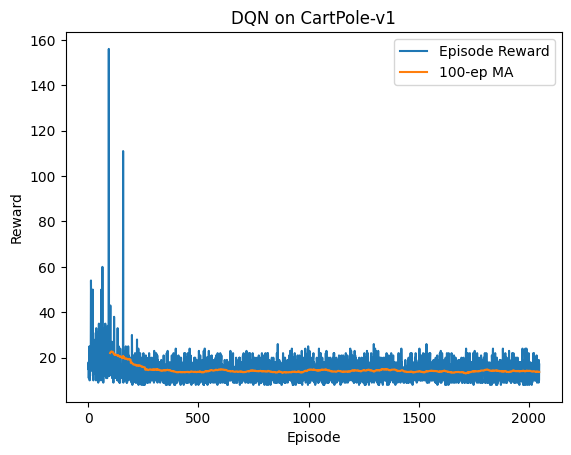

In [9]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

ma_rewards = moving_average(episode_rewards, 100)

plt.figure()
plt.plot(episode_rewards, label="Episode Reward")
plt.plot(range(99, len(episode_rewards)), ma_rewards, label="100-ep MA")
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on CartPole-v1")
plt.show()

In [10]:
if len(episode_rewards) >= 100:
    avg_last_100 = np.mean(episode_rewards[-100:])
    print("Average reward (last 100 episodes):", avg_last_100)
else:
    print("Not enough episodes for 100-episode average")

Average reward (last 100 episodes): 13.74


### Task 2 — PPO with Stable-Baselines3

Now do the same task — and one harder one — with a well-tuned library implementation.

1. Train a **PPO** agent on `CartPole-v1`:

```python
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

env = gym.make("CartPole-v1")
ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_cartpole, env, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")
```

2. Train a second PPO agent on `LunarLander-v2` with the same hyperparameters but **300 000 total timesteps** (this environment is much harder than CartPole).

```python
env_ll = gym.make("LunarLander-v2")
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")
```

3. Use Stable-Baselines3's built-in `Monitor` wrapper or its logger to capture the per-episode rewards during training for both runs, and plot 100-episode moving-average reward curves for both environments.

**Expected behaviour.** PPO solves `CartPole-v1` (reward ≥ 195 on average) within ~20 000 timesteps and reliably reaches the 500 cap. On `LunarLander-v2` PPO usually clears the 200-reward "solved" threshold somewhere between 150 000 and 300 000 timesteps.


In [11]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
env = Monitor(gym.make("CartPole-v1"))
ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)

In [12]:
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

In [13]:
mean_reward, std_reward = evaluate_policy(ppo_cartpole, env, n_eval_episodes=20)

print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")

PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 73s)


In [14]:
cartpole_rewards = env.get_episode_rewards()

In [15]:
env_ll = Monitor(gym.make("LunarLander-v3"))
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)

C:\Users\User\anaconda3\envs\rl_env\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [16]:
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

In [17]:
mean_reward, std_reward = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)

print(f"PPO LunarLander: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")

PPO LunarLander: 66.7 ± 127.0 over 20 episodes (trained in 449s)


In [18]:
ll_rewards = env_ll.get_episode_rewards()

In [19]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

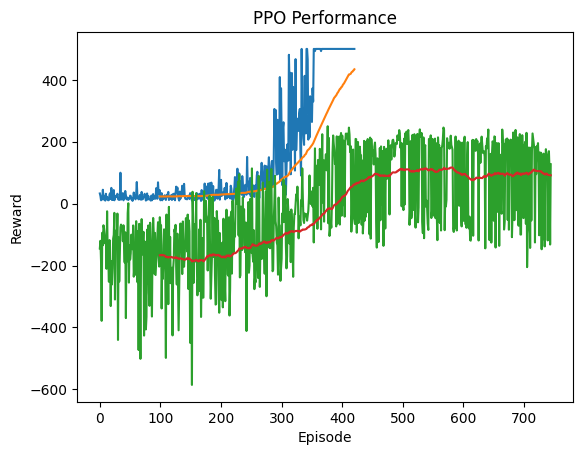

In [20]:
plt.figure()

cp_ma = moving_average(cartpole_rewards, 100)
plt.plot(cartpole_rewards)
plt.plot(range(99, len(cartpole_rewards)), cp_ma)

ll_ma = moving_average(ll_rewards, 100)
plt.plot(ll_rewards)
plt.plot(range(99, len(ll_rewards)), ll_ma)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Performance")
plt.show()

### Task 3 — Comparison and Reflection

Fill in this table from your runs in Tasks 1 and 2:

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1 | … | … |
| PPO (SB3) | CartPole-v1 | … | … |
| PPO (SB3) | LunarLander-v2 | … | … |

Then, in a markdown cell, answer the following questions in 3–5 sentences each:

1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?
2. Could you imagine training the **same DQN code** on `LunarLander-v2` and getting a similar result? What would you expect to go wrong, and which Deep RL improvement from the lesson (Double DQN, Dueling, PER, Rainbow) would you reach for first?
3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?


| Agent              | Environment        | Wall-clock training time | Avg reward (last 100 episodes) |
|--------------------|-------------------|--------------------------|---------------------------------|
| DQN (from scratch) | CartPole-v1       | 5.68 s                    | 13.74                          |
| PPO (SB3)          | CartPole-v1       | 73 s                    | 500.0                          |
| PPO (SB3)          | LunarLander-v3    | 449 s                    | ~66.7                          |


#### 1. Did DQN or PPO solve CartPole faster? Why?

In my results, PPO clearly solved CartPole while DQN completely failed to learn. PPO reached the maximum reward of 500 consistently, while DQN stayed around 13, indicating no meaningful learning. This is likely because PPO is more stable and does not rely on replay buffers and target networks, which are harder to tune correctly. My DQN implementation likely has a bug or instability that prevented proper convergence.

#### 2. Would DQN work on LunarLander? What would go wrong?

Given that my DQN did not even solve CartPole, it would almost certainly fail on LunarLander. This environment is more complex, with sparse rewards and harder dynamics, which would amplify DQN’s weaknesses. The most likely issues would be unstable Q-value estimation and poor exploration. The first improvement I would try is **Double DQN**, since it reduces overestimation bias and improves stability.

#### 3. DQN vs SB3 in real projects?

Based on these results, using Stable-Baselines3 is far more reliable than implementing DQN from scratch. PPO worked out-of-the-box and achieved strong performance with minimal tuning. In contrast, my DQN required careful debugging and still failed. For real-world applications, using a well-tested library is the better choice, while custom implementations are mainly useful for learning and experimentation.